In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("sales_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (100, 7)

First 5 rows:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


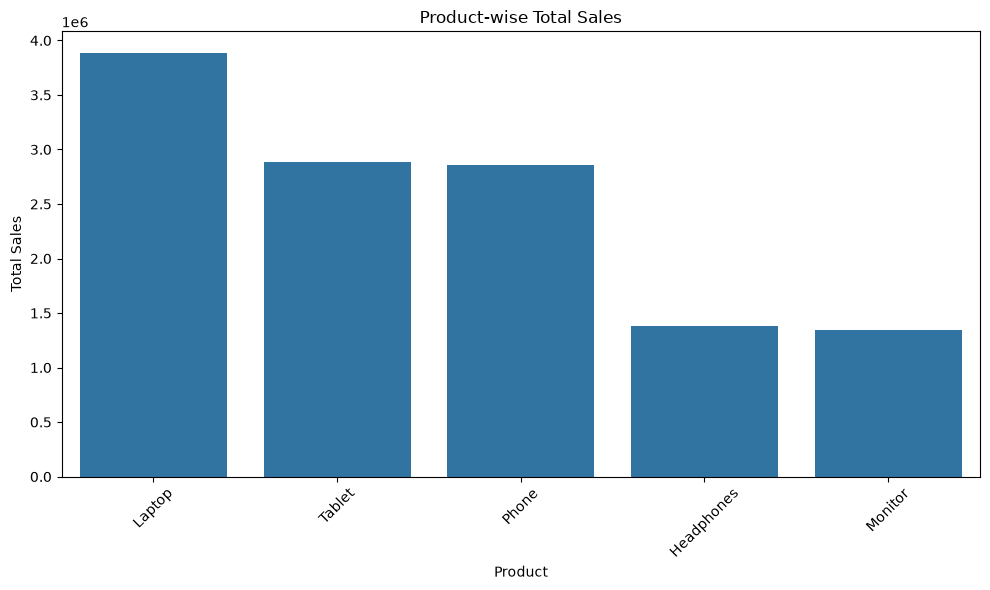

In [3]:
# Product-wise Sales Bar Chart

product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_sales.index,
    y=product_sales.values
)

plt.title("Product-wise Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

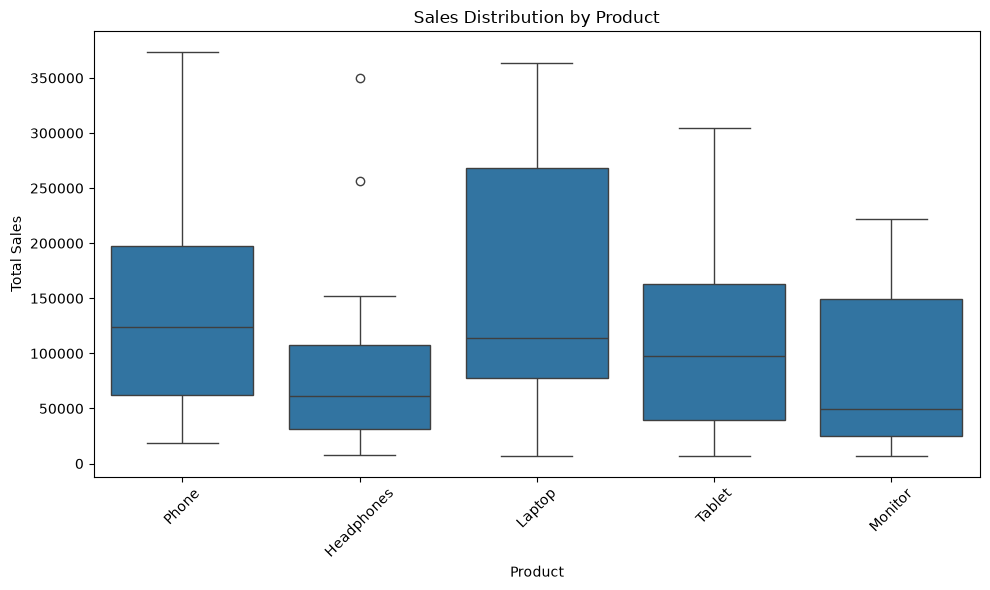

In [4]:
# Sales Distribution Box Plot

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Product",
    y="Total_Sales",
    data=df
)

plt.title("Sales Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

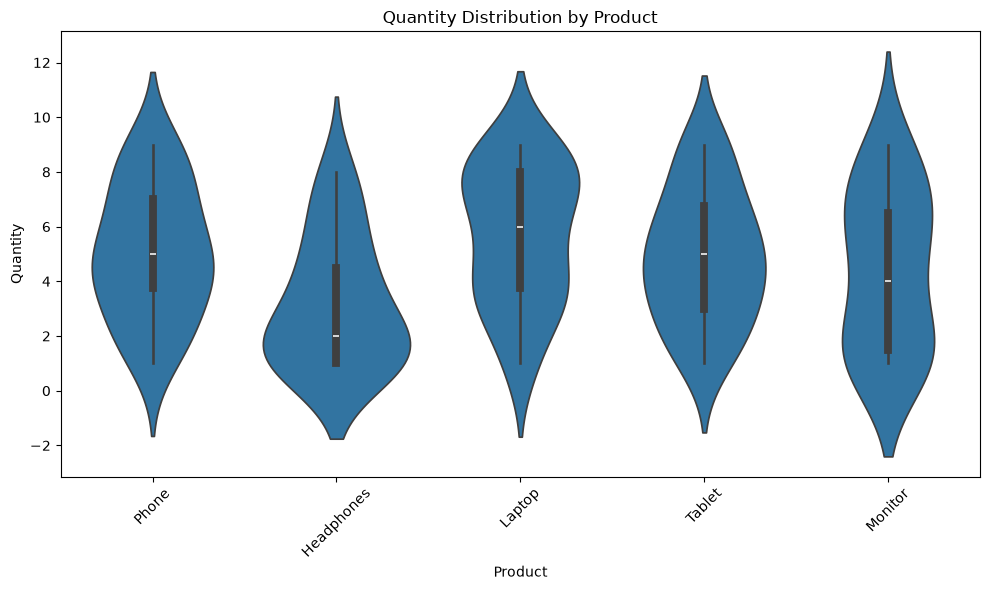

In [5]:
# Quantity Distribution Violin Plot

plt.figure(figsize=(10, 6))

sns.violinplot(
    x="Product",
    y="Quantity",
    data=df
)

plt.title("Quantity Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

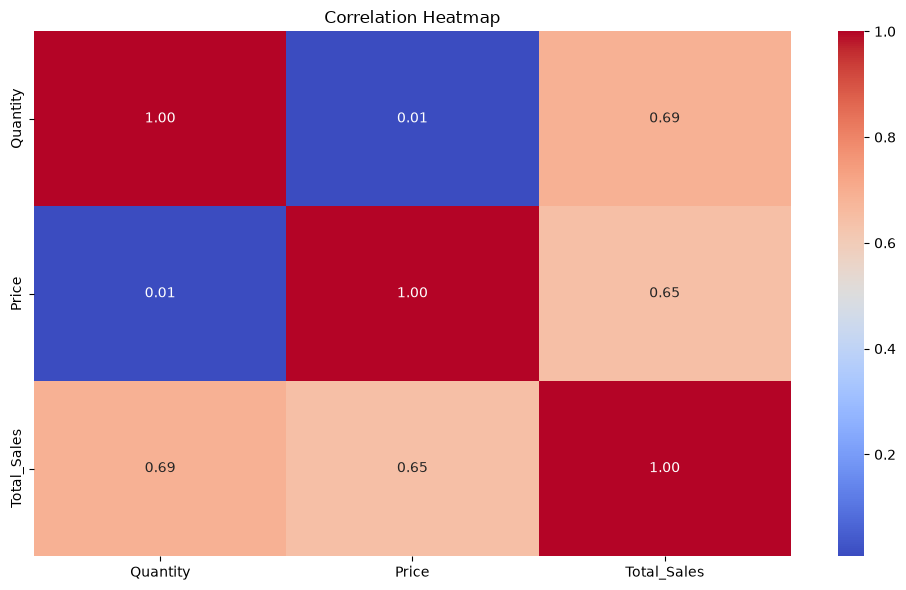

In [6]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

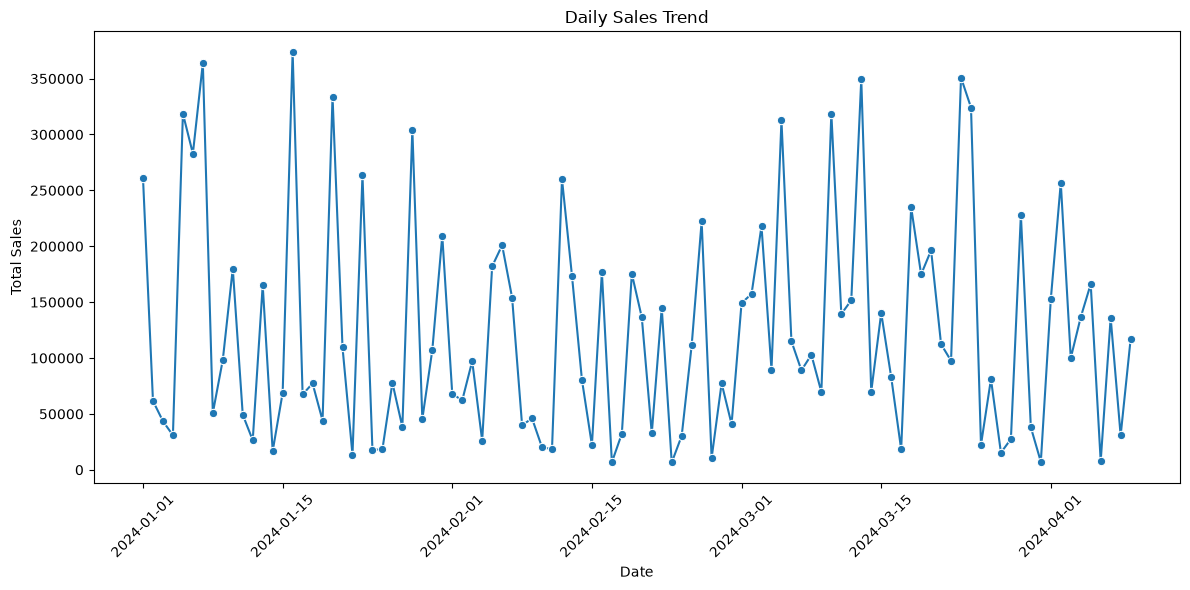

In [7]:
# Daily Sales Trend

daily_sales = (
    df.groupby("Date")["Total_Sales"]
    .sum()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=daily_sales.index,
    y=daily_sales.values,
    marker="o"
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


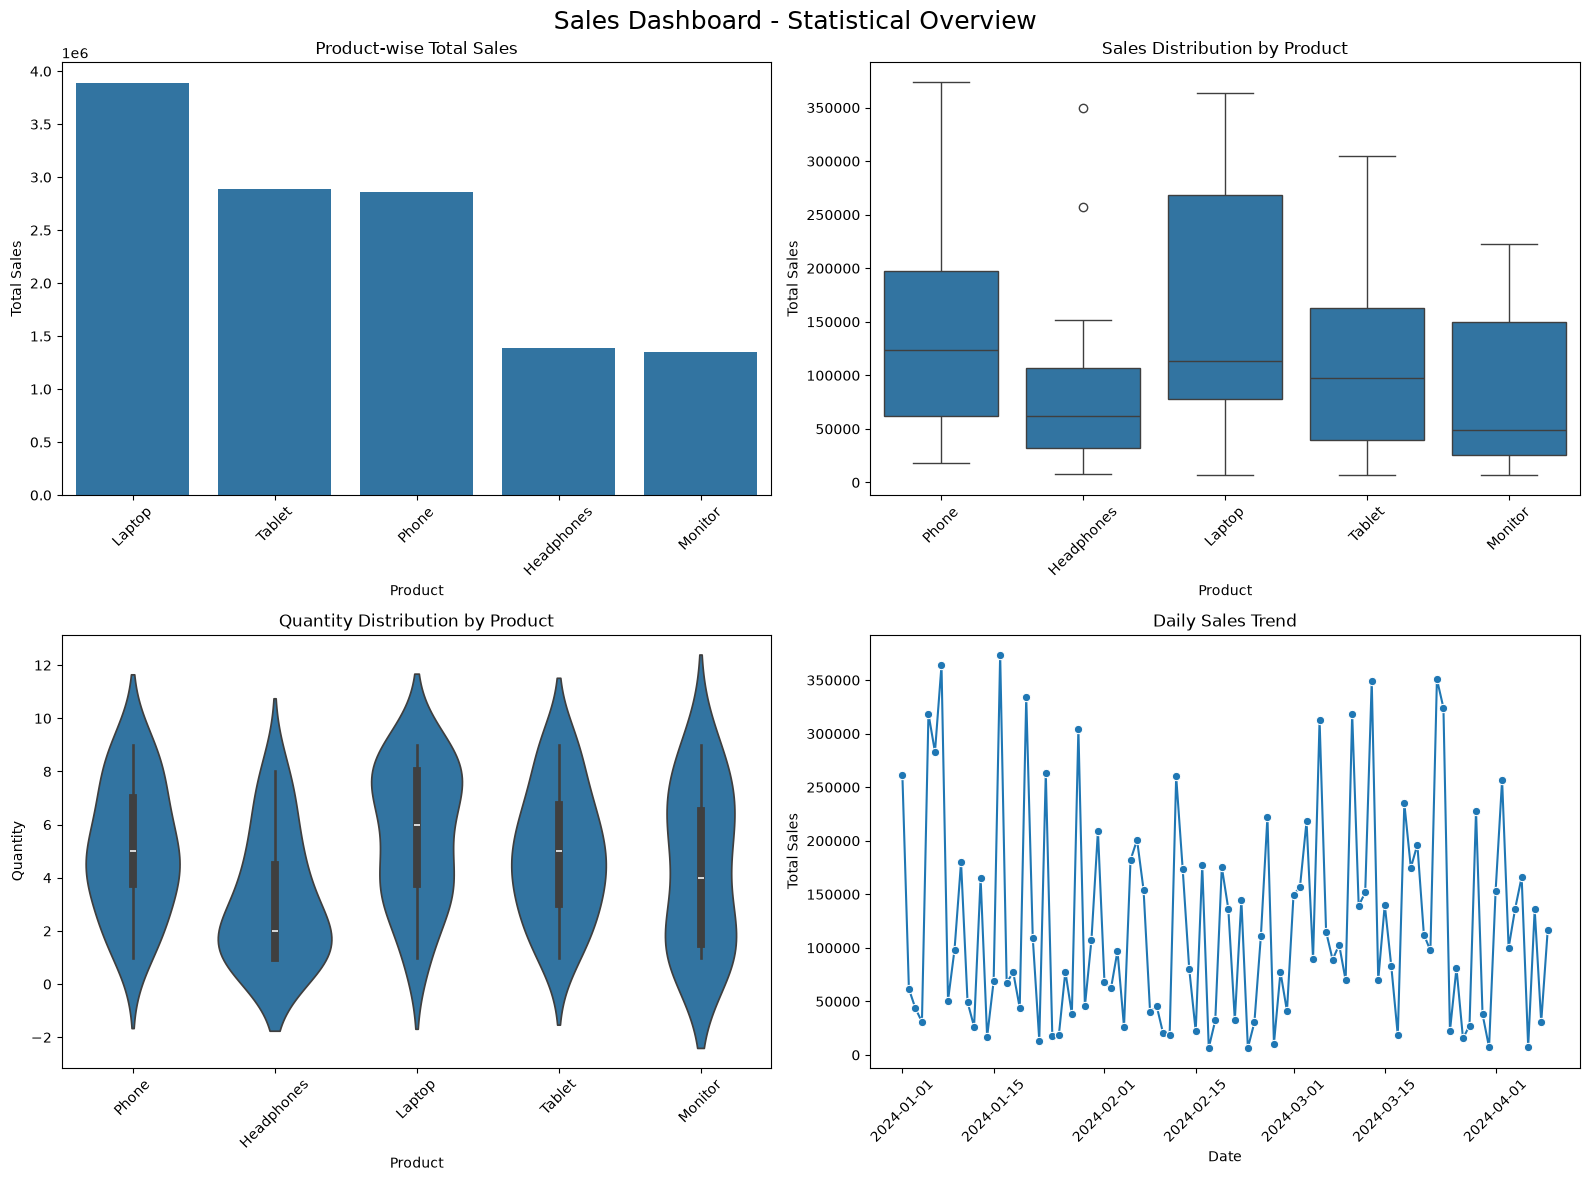

In [8]:
# 2x2 Sales Dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Product Sales
sns.barplot(
    x=product_sales.index,
    y=product_sales.values,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Product-wise Total Sales")
axes[0, 0].set_xlabel("Product")
axes[0, 0].set_ylabel("Total Sales")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Sales Distribution
sns.boxplot(
    x="Product",
    y="Total_Sales",
    data=df,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Sales Distribution by Product")
axes[0, 1].set_xlabel("Product")
axes[0, 1].set_ylabel("Total Sales")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Quantity Distribution
sns.violinplot(
    x="Product",
    y="Quantity",
    data=df,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Quantity Distribution by Product")
axes[1, 0].set_xlabel("Product")
axes[1, 0].set_ylabel("Quantity")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Daily Sales Trend
sns.lineplot(
    x=daily_sales.index,
    y=daily_sales.values,
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Daily Sales Trend")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Total Sales")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.suptitle(
    "Sales Dashboard - Statistical Overview",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [9]:
# Interactive Plotly Chart

fig = px.scatter(
    df,
    x="Price",
    y="Total_Sales",
    color="Product",
    hover_data=[
        "Date",
        "Quantity",
        "Region",
        "Customer_ID"
    ],
    title="Interactive Price vs Total Sales"
)

fig.update_layout(
    xaxis_title="Price",
    yaxis_title="Total Sales"
)

fig.show()